# Exploratory Data Analysis

The dataset contains flight booking data scraped from "Ease my trip". Data for the two "classes" economy and business class were merged. The regression task is to predict the flight price (in Indian Rupees).

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

### Dataset Overview and Characteristics

In [2]:
df = pd.read_csv("../data/raw/flight_dataset.csv")
print(df.head())
print(df.shape)

   Unnamed: 0   airline   flight source_city departure_time stops  \
0           0  SpiceJet  SG-8709       Delhi        Evening  zero   
1           1  SpiceJet  SG-8157       Delhi  Early_Morning  zero   
2           2   AirAsia   I5-764       Delhi  Early_Morning  zero   
3           3   Vistara   UK-995       Delhi        Morning  zero   
4           4   Vistara   UK-963       Delhi        Morning  zero   

    arrival_time destination_city    class  duration  days_left  price  
0          Night           Mumbai  Economy      2.17          1   5953  
1        Morning           Mumbai  Economy      2.33          1   5953  
2  Early_Morning           Mumbai  Economy      2.17          1   5956  
3      Afternoon           Mumbai  Economy      2.25          1   5955  
4        Morning           Mumbai  Economy      2.33          1   5955  
(300153, 12)


The dataset overview reveals the dataset contains 10 features (without the target variable 'price' and the unique identifier column). Moreover, the dataset contains 300,153 samples. 

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  str    
 2   flight            300153 non-null  str    
 3   source_city       300153 non-null  str    
 4   departure_time    300153 non-null  str    
 5   stops             300153 non-null  str    
 6   arrival_time      300153 non-null  str    
 7   destination_city  300153 non-null  str    
 8   class             300153 non-null  str    
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), str(8)
memory usage: 27.5 MB


The dataset contains mostly categorical features, with duration (float) and days_left (int) being the only numerical features present in the dataset. As a consequence, encoding of categorical variables will be vital for the regression task. Some features could be transformed in terms of datatype, such as 'stops'.

In [4]:
df.nunique()

Unnamed: 0          300153
airline                  6
flight                1561
source_city              6
departure_time           6
stops                    3
arrival_time             6
destination_city         6
class                    2
duration               476
days_left               49
price                12157
dtype: int64

Looking at unique values reveals that many flights ('flight', letter and number identifier) are repeated throughout the dataset, with a total of 1,561 unique flights. Moreover, there are a total of 6 unique airlines in this dataset. The same applies to source/destination city and departure/arrival time, with a total of 6 cities present in the dataset and 6 different categorical times of the day. The feature 'days_left' counts 49 unique values, suggesting that the time prior to flight departure reaches lengths of more than 30 days, which likely impacts flight pricing. 

In [13]:
df['stops'].unique()

<StringArray>
['zero', 'one', 'two_or_more']
Length: 3, dtype: str

Getting the concrete unique values of the feature 'stops'.

In [5]:
print(df.describe(include='str'))

        airline  flight source_city departure_time   stops arrival_time  \
count    300153  300153      300153         300153  300153       300153   
unique        6    1561           6              6       3            6   
top     Vistara  UK-706       Delhi        Morning     one        Night   
freq     127859    3235       61343          71146  250863        91538   

       destination_city    class  
count            300153   300153  
unique                6        2  
top              Mumbai  Economy  
freq              59097   206666  


Looking at descriptive statistics for categorical features reveals that the highest frequency for 'source_city' is Delhi, which might be explainable by it being the capital city. The highest frequency in terms of 'departure_time' is held by "Morning", which is likely due to the mean 'duration' being approx. 12 hours, resulting in an arrival at evening or night time. Given this dataset represents domestic flights, this likely represents a considerable amount of business or visit trips. 

In [6]:
print(df.describe())

          Unnamed: 0       duration      days_left          price
count  300153.000000  300153.000000  300153.000000  300153.000000
mean   150076.000000      12.221021      26.004751   20889.660523
std     86646.852011       7.191997      13.561004   22697.767366
min         0.000000       0.830000       1.000000    1105.000000
25%     75038.000000       6.830000      15.000000    4783.000000
50%    150076.000000      11.250000      26.000000    7425.000000
75%    225114.000000      16.170000      38.000000   42521.000000
max    300152.000000      49.830000      49.000000  123071.000000


Looking at descriptive statistics for the numerical features, it can be seen that the mean number of days of booking before departure is 26 days with a standard deviation of about 13 days. The mean duration of the flights is about 12 hours with a standard deviation of about 7 hours. The quartiles for this feature and the maximum value indicate that it is right skewed with a max duration of 49 hours. The target variable 'price' shows large deviation, with the mean flight price being about 20,889 INR, the max price 123,071 INR, and the min price 1105 INR. Differences in price might be explainable by the different classes ('class') and length of flight ('duration', 'stops').

In [7]:
df.isnull().sum()

Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

The above output shows that neither the features nor the target variable contain any missing values. This is to be considered when it comes to data preparation.

In [8]:
df.duplicated().sum()

np.int64(0)

The same applies to duplicated values as seen in the output above. 

### Distribution and Outliers

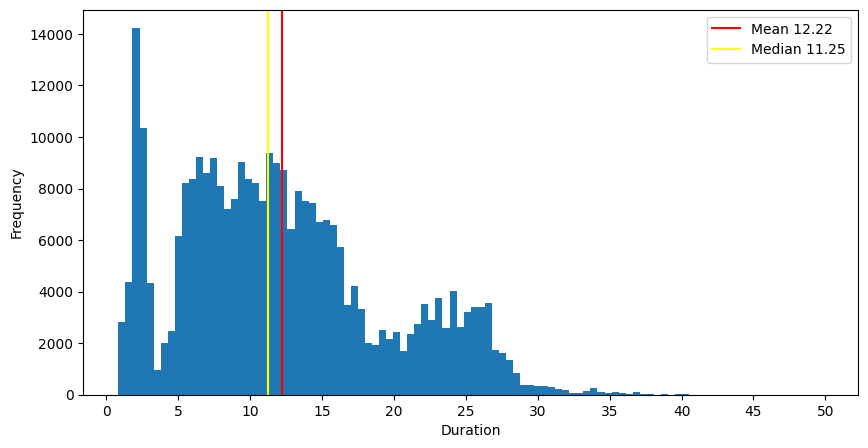

In [60]:
mean = df['duration'].mean()
median = df['duration'].median()

plt.figure(figsize=(10, 5))
plt.hist(df['duration'], bins=100)
plt.axvline(mean, color='red', label=f'Mean {mean:.2f}')
plt.axvline(median, color='yellow', label=f'Median {median:.2f}')
plt.xlabel('Duration')
plt.ylabel('Frequency')
plt.xticks(np.arange(0, 55, 5))
plt.legend()
plt.show()

This plot shows the distribution of the feature 'duration'. It confirms what has been found using the descriptitve statistics. The feature 'duration' is right-skewed, with the mean and median indicated in the plot with vertical lines. Moreover, the distribution seems to contain more than one mode, with two additional, noteable peaks at about 2.5 hours and 23 hours. 

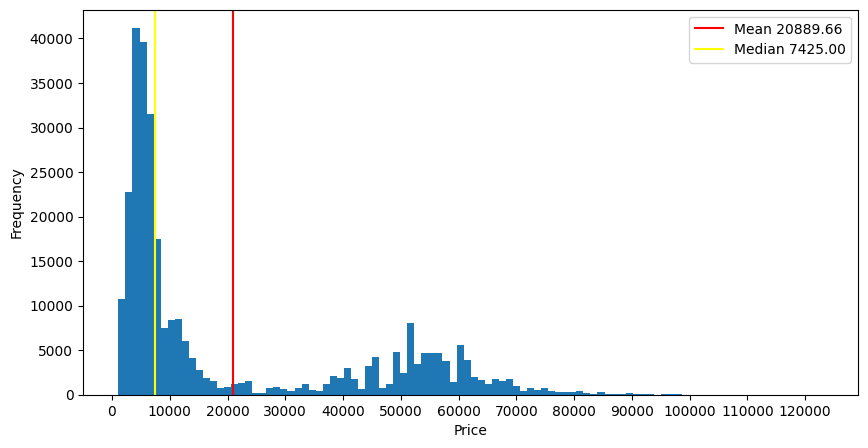

In [59]:
mean = df['price'].mean()
median = df['price'].median()

plt.figure(figsize=(10, 5))
plt.hist(df['price'], bins=100)
plt.axvline(mean, color='red', label=f'Mean {mean:.2f}')
plt.axvline(median, color='yellow', label=f'Median {median:.2f}')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.xticks(np.arange(0, 130000, 10000))
plt.legend()
plt.show()

This plot shows the distribution of the target variable 'price', the mean and median are indicated using vertical lines. It shows that the target variable is clearly right skewed, which might be considered when preprocessing the data (outlier handling, log-transform). The skewedness might be due to business class flights.

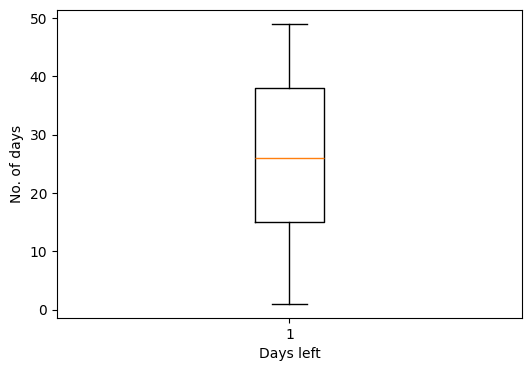

In [9]:
plt.figure(figsize=(6, 4))
plt.boxplot(df['days_left'])
plt.xlabel('Days left')
plt.ylabel('No. of days')
plt.show()

The above boxplot shows the distribution of the feature 'days_left'. It shows a visibly uniform distribution of samples, which does not warrant any outlier handling in preprocessing. 

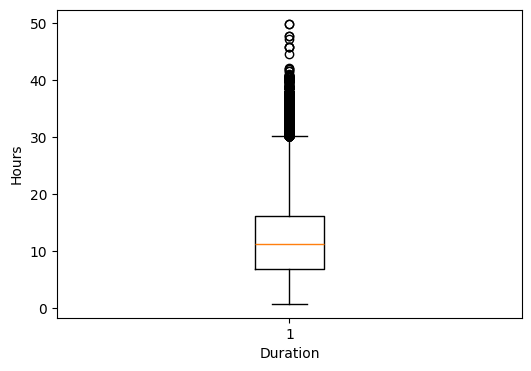

In [10]:
plt.figure(figsize=(6, 4))
plt.boxplot(df['duration'])
plt.xlabel('Duration')
plt.ylabel('Hours')
plt.show()

The above boxplot shows the distribution of the feature 'duration'. It can be observed that the feature entails a right-tailed disribution with a considerable number of outliers beyond the 1.5x IQR. It is neccessary to handle outliers in preprocessing for this feature.

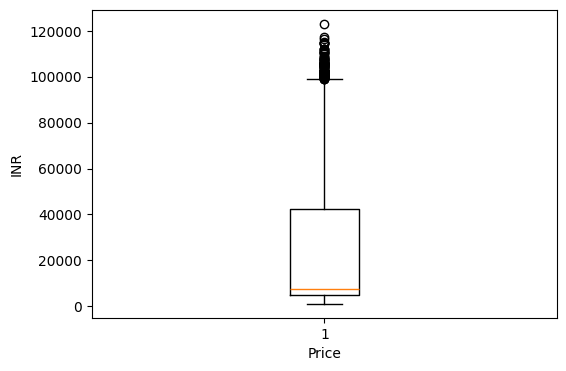

In [11]:
plt.figure(figsize=(6, 4))
plt.boxplot(df['price'])
plt.xlabel('Price')
plt.ylabel('INR')
plt.show()

The above boxplot shows the distribution of the target variable 'price'. It confirms the right-skewedness discussed in the histogram plot. The distribution shows a large Q3 and indicates that many values lie within 1.5x the IQR. Moreover, many outliers can be observed beyond 1.5 times the IQR, which clearly shows the necessity of handling outliers for the target variable. 